In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn import Accumulation_Site as Firn_Site

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

# Matlab Functions

In [3]:
#Credit to the top response of this stackoverflow question for converting the Matlab smooth function to python:
#https://stackoverflow.com/questions/40443020/matlabs-smooth-implementation-n-point-moving-average-in-numpy-python
def smooth(a,WSZ):
    # a: NumPy 1-D array containing the data to be smoothed
    # WSZ: smoothing window size needs, which must be odd number,
    # as in the original MATLAB implementation
    out0 = np.convolve(a,np.ones(WSZ,dtype=int),'valid')/WSZ    
    r = np.arange(1,WSZ-1,2)
    start = np.cumsum(a[:WSZ-1])[::2]/r
    stop = (np.cumsum(a[:-WSZ:-1])[::2]/r)[::-1]
    return np.concatenate((  start , out0, stop  ))

# smoothdiff(f,dx) differentiates f to x with timestep dx.
# df/dx = (0.5/dx)*([f f(N) f(N)]-[f(1) f(1) f]);
# what's going on here is we're taking the derivate over 2 steps of dx: df(i)/dx = (f[i+1]-f[i-1])/2dx
# at the edges, we just take the derivate over 1 step: df(0)/dx = (f[1]-f[0])/dx; df(-1)/dx = (f[-1]-f[-2])/dx
def smoothdiff(f,dx):
    #N = length(f);
    #if size(f,1) == 1
    #    out = (0.5/dx)*([f f(N) f(N)]-[f(1) f(1) f]); 
    #else
    #    out = (0.5/dx)*([f; f(N); f(N)]-[f(1); f(1); f]);     
    #end
    #out(N+2)=[]; out(1)=[];
    #out(N) = 2*out(N);
    #out(1) = 2*out(1);
    return np.concatenate(( [(f[1]-f[0])/dx], (0.5/dx)*(f[2:]-f[:-2]), [(f[-1]-f[-2])/dx] ), axis=0)

def C14_unit_convert(C14_in,unit_in,unit_out):#,date,d13C,MixR):
    # Constants
    Navo = 6.022140857E23
    scc_mol = 22414
    Aabs = 1.1764E-12
    tau = 8267
    
    # molec/ccSTP --> ppmE-12
    if (unit_in=='molec' and unit_out=='ppm'):
        return C14_in * scc_mol / Navo * 10**18

    # ppmE-12 -> molec/ccSTP
    if (unit_in=='ppm' and unit_out=='molec'):
        return C14_in / scc_mol * Navo / 10**18
    
def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd):
            x[i] = x[i-1]*np.exp(1/lambd)
        elif x[i]/x[i-1] < np.exp(-1/lambd):
            x[i] = x[i-1]*np.exp(-1/lambd)
    return x

## Accumulation Site

In [4]:
class Accumulation_Site:
    def __init__(self,
                 dz = 0.25, #m
                 z_end = 300, #m
                 N_over = 20, # points below close-off depth
                 dt = 0.01, #yrs
                 t_end = 3000, #yrs
                 t_resol = 0.5, #yrs
                 t_sample = 1999.05, # sample date
                 dens_file = 'Firn_Model_Density_DomeC.csv',
                 tort_file = 'Firn_Model_Tortuosity_DomeC.csv',
                 # Constant 14CO atmospheric concentration
                 # full average of available NIWA ARH measurements provided by Hinrich
                 gases = {'C14_CO'},
                 C14CO_const = 12, # constant 14CO history (molec/ccSTP)
                 #
                 pressure = 65800, # air pressure (Pa)
                 T = -54, # Temp (C)
                 Acc = 0.033, # Accumulation rate (meters of ice / yr)
                 Lockin = 96, #lock-in depth
                 Closeoff = 100, # close-off depth
                 D_0eddy = 2.55e-5, # convective diffusivity const.
                 H_eddy = 3, #1/e depth of convective layer
                ):
        
        self.pressure = pressure
        self.T = T+273.15
        self.Acc = Acc
        self.Lockin = Lockin
        self.Closeoff = Closeoff
        self.D_0eddy = D_0eddy
        self.H_eddy = H_eddy
        
        self.R = 8.314472 # gas constant (J/mol K)
        self.g = 9.82 # gravity (m/s^2)
        self.M_air = 28.96e-3 # molar mass of air (kg/mol)
        
        self.set_space_mesh(dz, z_end, N_over)
        
        self.set_time_mesh(dt, t_end, t_resol, t_sample)
        
        self.set_density(dens_file)
        
        self.load_tortuosity(tort_file)
        
        self.set_air_occlusion()
        
        self.load_gas_properties(gases)
        
        self.set_gas_history(C14CO_const)
        
        self.Crank_abc()
        
    def set_space_mesh(self, dz, z_end, N_over):
        
        z_end = max(z_end, round(self.Closeoff + N_over * dz))
        z = np.arange(0, z_end+1e-10, dz) #I add 1e-10 to the endpoint to try to match the inclusive endpoint of matlab's : operator
        N = len(z)
        
        self.dz = dz
        self.z_end = z_end
        self.N_over = N_over
        self.z = z
        self.N = N
        
    def set_time_mesh(self, dt, t_end, t_resol, t_sample):
        
        t_low = np.arange(t_sample-t_end, t_sample+1e-10, t_resol)
        t_high = np.arange(t_sample-t_end, t_sample+1e-10, dt)
        M = len(t_high)
        P = len(t_low)
        P2 = int(t_resol/dt)
        
        self.dt = dt
        self.t_end = t_end
        self.t_resol = t_resol
        self.t_sample = t_sample
        self.t_low = t_low
        self.t_high = t_high
        self.M = M
        self.P = P
        self.P2 = P2
    
    def set_density(self, dens_file):
        
        rho_ice = 0.9165 - (self.T-273.15)*1.4438e-4 - (self.T-273.15)**2 * 1.5175e-7 # Schwander et al.
        rho_co = 0.833 # density at close off depth? idk

        dens = np.array(pd.read_csv(dens_file))

        # starting at 120m, exponential decay towards rho_ice
        dens = np.concatenate((dens[:-1], np.array([np.arange(dens[-1,0], 200+1e-10, 0.2), ( dens[-1,1] + (rho_ice - dens[-1,1]) * (1-np.exp(-0.047 * (np.arange(dens[-1,0], 200+1e-10, 0.2) - 120))))]).T), axis=0)
        dens[:,1] = smooth(dens[:,1], 9) #apply smoothing function

        rho = np.interp(self.z, dens[:,0], dens[:,1])

        IceAge = scipy.integrate.cumulative_trapezoid(rho, dx=self.dz, initial=0) / (rho_ice * self.Acc)

        s = 1 - rho/rho_ice # porosity of ice by depth
        s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
        s_open = s - s_closed # open porosity

        teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)
        
        self.dens_file = dens_file
        self.rho_ice = rho_ice
        self.rho_co = rho_co
        self.dens = dens
        self.rho = rho
        self.IceAge = IceAge
        
        self.s = s
        self.s_closed = s_closed
        self.s_open = s_open
        self.teller_co = teller_co
        
    def load_tortuosity(self, tort_file):
        
        Profiles = np.array(pd.read_csv(tort_file))
        self.InvTort = np.interp(self.z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
        self.Diff_m = np.interp(self.z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone
        self.tort_file = tort_file
        
    def set_air_occlusion(self):
        
        bubble_pres = np.zeros(self.z.shape)

        dscl = np.diff(self.s_closed, prepend=self.s_closed[0])/self.dz # ds_closed / dz

        #s = s_open + s_closed # why not just use the old s value?
        C = np.exp(self.M_air * self.g * self.z / (self.R * self.T) )
        v_ice = self.Acc * self.rho_ice / self.rho # downwards ice velocity
        #strain = smoothdiff( np.log(v_ice), self.dz ) # d log(v_ice) / dz
        
        bubble_pres = self.dz*(np.cumsum(dscl*C*self.s)*(1+np.log(v_ice)) - np.cumsum(dscl*C*self.s*np.log(v_ice)))/(self.s_closed-self.s_closed[0])/self.s
        #print(time()-t)

        # integrating the bubble pressure from the surface down to the close-off depth?
        # After teller_co:
        
        teller_co = self.teller_co
        bubble_pres[teller_co+1:] = bubble_pres[teller_co] * self.s[teller_co] / self.s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
        # bubble pres is directly inverse to s and v_ice below close-off depth

        # the initial division has a divide by zero error at the first index, so we set that to 1 now.
        bubble_pres[0] = 1 # what are the units here??

        flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * self.s_closed[teller_co+1]

        velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * self.s_closed) / ((self.s_open + 1e-10) * C) )

        air_content = 1000 * bubble_pres[teller_co+1] * self.s_closed[teller_co+1] * self.pressure / 101325 * 273.15 / self.T / self.rho[teller_co+1]
        
        self.v_ice = v_ice
        self.bubble_pres = bubble_pres
        self.flux = flux
        self.velocity = velocity
        self.air_content = air_content
        
    def load_gas_properties(self, gases):
        
        D_ref_CO2 = 5.75e-10 * self.T**1.81 * 101325 / self.pressure # CO2 diffusivity

        M_gas, D_gas, decay_gas = dict(), dict(), dict()
        for g in gases:
            if g == 'C14_CO':
                M_gas[g] = 30e-3 # molar weight [kg/mol]
                D_gas[g] = D_ref_CO2 * 1.25 * 0.9829926 # free air diffusivity w/ “sqrt of ratio of reduced masses”
                decay_gas[g] = 1/8267 # 1/mean lifetime [1/yr]
        
        self.gases = gases
        self.M_gas = M_gas
        self.D_gas = D_gas
        self.decay_gas = decay_gas
        
    def set_gas_history(self, C14CO_const):
        
        gas_history = dict()
        for g in self.gases:
            if g == 'C14_CO':
                gas_history['C14_CO'] = C14_unit_convert(C14CO_const, 'molec', 'ppm') * np.ones(self.M)
        
        self.gas_history = gas_history
        self.C14CO_const = C14CO_const
        
    def Crank_abc(self):
        
        alpha, beta, gamma = dict(), dict(), dict()
        
        for g in self.gases:
            teller_co = np.arange(len(self.s_open))[self.s_open==0][0]
            s = self.s
            s_open = self.s_open + 1e-9     # add a small number to make sure 1/s_open doesn't blow up
            C_air = np.exp(self.M_air*self.g*self.z/(self.R*self.T))  # Barometric equation

            velocity = self.velocity/(60*60*24*365.25) # convert to m/s
            L_trace = self.decay_gas[g]/(60*60*24*365.25)

            # Molecular diffusivity part:
            Diff   =  self.InvTort*self.D_gas[g]

            M_trace = self.M_gas[g]

            # Eddy diffusivity part:
            Diff_e = efilter(self.D_0eddy*np.exp(-self.z/self.H_eddy),0.5/self.dz)*(self.z<55) # Convection following Kawamura et al
            Diff_e = np.maximum(Diff_e,self.Diff_m)    # Add dispersion in the LIZ

            # Take the derivatives
            porecl = smoothdiff(Diff*C_air*s_open,self.dz)/(s_open*C_air)
            porecl_e = smoothdiff(Diff_e*C_air*s_open,self.dz)/(s_open*C_air)

            porecl[teller_co]   = porecl[teller_co+1]
            porecl_e[teller_co] = porecl_e[teller_co+1]

            # c_t = alpha*c_zz + beta*c_z + gamma*c
            alpha[g] =  (self.dt*60*60*24*365.25/(2*self.dz**2)) * (Diff+Diff_e)
            beta[g]  =  (self.dt*60*60*24*365.25/(4*self.dz)) * (Diff*(self.M_air-M_trace)*self.g/(self.R*self.T) + (Diff_e)*(self.M_air)*self.g/(self.R*self.T) + porecl + porecl_e -velocity)
            gamma[g] =  (self.dt*60*60*24*365.25/2) * (porecl*(self.M_air-M_trace)*self.g/(self.R*self.T) +  -L_trace)
        
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        
        return

In [5]:
def COS_Production(Site, z, scaling_site = [16.95], P0_tuning = np.ones(3)):
    Pn0_SLHL = 12.76 # Borchers ‘16
    QtzToIce = 60.08 / 2 / 18.02 # conversion for O-atom density difference between quartz and ice

    Pn = Pn0_SLHL * QtzToIce * scaling_site[0] * P0_tuning[0] * np.exp(-100 * z * Site.rho_ice/150)

    Balco_mu_neg, Balco_mu_fast = F.Balco_P_mu_total(100*z*Site.rho_ice, Site.pressure/100)

    Pmu = Balco_mu_neg * P0_tuning[1]
    Pmuf = Balco_mu_fast * P0_tuning[2]
    
    return Pn, Pmu, Pmuf

In [6]:
#R, L = 0.0044, 0.0045 #default Retention and Leakage
R, L = 0.01, 0.0007
#f_factors = np.array([1.03, 0.065, 0.07]) # minimal f-factors
f_factors = np.array([1., 0.0584, 0.0687]) # Vas test values

COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

f_factors = np.array(f_factors)
P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]])
# remove 14CO/14C fraction

# Divide 14CO between Reservoirs 1 & 2
Res_partition = np.array([1-R, R])
Res_partition = Res_partition / np.sum(Res_partition) # normalize to sum = 1

def Calc_14C_ice(Site,
                 COS_timesteps = 1, # int number of timesteps between t_resol output values (1-5)
                 L = [1., 0.0045, 0.0001], # Leakage rates by Reservoir
                 op_cl_prob_ratio = 1, # relative probability of leakage into open vs closed porosity per equiv. volume of each type
                ):
    
    L = np.array(L)
    
    Q = 1 + (COS_timesteps * (Site.P-1))
    COS_dt = Site.t_resol / COS_timesteps
    #COS_t = Site.t_sample - np.arange(Site.t_end, -1e-10, -COS_dt)
    COS_t = np.arange(Site.t_sample-Site.t_end, Site.t_sample+1e-10, COS_dt)

    #ice-eqiv depth
    COS_dz = Site.Acc * COS_dt
    COS_z = np.arange(COS_dz/2, Site.dz * np.sum(Site.rho)/Site.rho_ice + 2 * Site.dz, COS_dz) # depth bin centers

    # interpolate COS_z to real depth, integrating “dummy” density to get mass depth ranges
    COS_zr = np.interp(COS_z, scipy.integrate.cumulative_trapezoid([*Site.rho, Site.rho_ice], x=[*Site.z, Site.z[-1]+30], initial=0)/Site.rho_ice, [*Site.z, Site.z[-1]+30])

    # Get Production Rates
    COS_Pn, COS_Pmu, COS_Pmuf = COS_Production(Site, z=COS_z)
    COS_P = np.array([COS_Pn, COS_Pmu, COS_Pmuf]).T
    
    # Run the calculation
    COS_age = (np.arange(len(COS_z))*COS_dt+COS_dt/2).reshape((-1,1,1)) # age of ice at ice-eq depth COS_z

    lambd = 1/8267 #14C decay rate
    # integrate total leakage over time
    Lrate = -np.log(1-L)
    # integrate new 14C production rate - loss to decay & leakage
    Ctemp = np.exp(-(lambd+Lrate)*COS_age) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
    Ctemp[~np.isfinite(Ctemp)] = 0
    #axis0 - Depth (=Ice Age)
    #axis1 - Production Mode (n0, mu-, muf)
    #axis2 - Reservoir

    #14C Concentration in ice grains
    grains = Ctemp
    
    o = np.interp(COS_zr, Site.z, Site.s_open)
    c = np.interp(COS_zr, Site.z, Site.s_closed)
    
    l_o = o * op_cl_prob_ratio/(o * op_cl_prob_ratio + c)
    l_c = c/(o * op_cl_prob_ratio + c)

    #14C leaked into open porosity per timestep
    leak_open = (Ctemp/COS_dt + COS_P.reshape((-1,3,1))) * (1-(1-L)**COS_dt).reshape((1,1,-1)) * l_o.reshape((-1,1,1))
    #14C leaked into closed porosity per timestep
    leak_closed = (Ctemp/COS_dt + COS_P.reshape((-1,3,1))) * (1-(1-L)**COS_dt).reshape((1,1,-1)) * l_c.reshape((-1,1,1))

    #14C stored in open porosity (no bubble tracking)
    cumuleak_open = np.exp(-lambd*COS_age) * np.cumsum(leak_open * np.exp(lambd*COS_age) * COS_dt, axis=0)
    #14C stored in closed porosity (no bubble tracking)
    cumuleak_closed = np.exp(-lambd*COS_age) * np.cumsum(leak_closed * np.exp(lambd*COS_age) * COS_dt, axis=0)
    #axis0 - Depth (=Ice Age)
    #axis1 - Production Mode (n0, mu-, muf)
    #axis2 - Reservoir

    grains_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),grains), axis=0), axis=0, assume_sorted=True)(Site.z)
    leak_open_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),leak_open), axis=0), axis=0, assume_sorted=True)(Site.z)
    leak_closed_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),leak_closed), axis=0), axis=0, assume_sorted=True)(Site.z)
    cumuleak_open_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),cumuleak_open), axis=0), axis=0, assume_sorted=True)(Site.z)
    cumuleak_closed_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),cumuleak_closed), axis=0), axis=0, assume_sorted=True)(Site.z)

    #C14_grains = np.repeat(grains_z.reshape((grains_z.shape[0],1,*grains_z.shape[1:])), Site.P, axis=1)
    #C14_leak_open = np.repeat(leak_open_z.reshape((leak_open_z.shape[0],1,*grains_z.shape[1:])), Site.P, axis=1)
    #C14_leak_closed = np.repeat(leak_closed_z.reshape((leak_closed_z.shape[0],1,*grains_z.shape[1:])), Site.P, axis=1)
    #C14_cumuleak_open = np.repeat(cumuleak_open_z.reshape((cumuleak_open_z.shape[0],1,*grains_z.shape[1:])), Site.P, axis=1)
    #C14_cumuleak_closed = np.repeat(cumuleak_closed_z.reshape((cumuleak_closed_z.shape[0],1,*grains_z.shape[1:])), Site.P, axis=1)
    #axis0 - Depth
    #axis1 - Time
    #axis2 - Production Mode (n0, mu-, muf)
    #axis3 - Reservoir
    
    # Calculate 14CO production below close-off depth, with no leakage
    COS_P_co = np.copy(COS_P)
    COS_P_co[COS_zr<Site.z[Site.teller_co]] = 0

    noleak_co = np.exp(-lambd*COS_age) * np.cumsum(COS_P_co.reshape((-1,3,1)) * np.exp(lambd*COS_age) * COS_dt, axis=0)
    noleak_co_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*noleak_co.shape[1:])),noleak_co), axis=0), axis=0, assume_sorted=True)(Site.z)
    C14_noleak = noleak_co_z[:,:,0].reshape((-1,3))
    #axis0 - Depth
    #axis1 - Production Mode (n0, mu-, muf)
    
    return grains_z, leak_open_z, cumuleak_closed_z, C14_noleak

In [7]:
def CrankNic(Site, gas, C14_add, eig=True):
    # this solves the diffusion equation c_t = alpha*c_xx + beta*c_x + gamma*c 
    # using finite-differences in space and Crank-Nicolson time-stepping.  
    # t_0 is the initial time, t_end is the final time, N is the number of mesh-points, 
    # and M is the number of time steps.
    
    alpha = Site.alpha[gas]
    beta = Site.beta[gas]
    gamma = Site.gamma[gas]

    Q = min(Site.teller_co+Site.N_over, Site.N)
    
    if len(C14_add)<Q:
        C14_add = np.concatenate((C14_add, np.zeros((Q-len(C14_add), *C_14_add.shape[1:]))), axis=0)
    
    A_for = scipy.sparse.diags_array(
        [
            np.concatenate((alpha[1:Q] - beta[1:Q], [0])),
            np.concatenate(([1], 1-2*alpha[1:Q]+gamma[1:Q], [0])),
            np.concatenate(([0], alpha[1:Q] + beta[1:Q] )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    A_back = scipy.sparse.diags_array(
        [
            np.concatenate((-1*(alpha[1:Q] - beta[1:Q]), [-1])),
            np.concatenate(([1], 1+2*alpha[1:Q]-gamma[1:Q], [1])),
            np.concatenate(([0], -1*(alpha[1:Q] + beta[1:Q]) )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    
    A_inv = scipy.sparse.linalg.inv(A_back)
    
    A_tot = A_inv @ A_for
    A_tot[0] = 0
    
    if eig:
        #A_val, A_vec = np.linalg.eig(A_tot.toarray())

        # solve for the limit assuming constant input
        #c_temp = A_vec @ (((1-A_val**(Site.M-1))/(1-A_val)).reshape((-1,1)) * (A_vec.T @ C14_add[:Q]))
        #c_temp[:,0] += A_vec @ ((A_val**(Site.M-1)) * (A_vec.T @ (C14_add[0,0] * np.ones(Q))))
        
        c_temp = scipy.sparse.linalg.inv(scipy.sparse.identity(Q) - A_tot) @ C14_add[:Q]
    
    else:
        # Initialise the firn with constant mixing ratio throughout
        c_temp = np.zeros((Q,*C14_add.shape[1:]))
        c_temp[:,0] = C14_add[0,0]

        for j in tqdm(range(Site.M-1)):
            #RHS = A_for @ c_temp

            #c_temp = A\RHS; % Matrix inversion!! Go MATLAB!!
            #c_temp = A_inv @ RHS # I already did the matrix inversion... Go Python!!

            #c_temp[0] = 0
            #c_temp = c_temp + C14_add[:Q]
            c_temp = A_tot @ c_temp + C14_add[:Q]
    
    c_gases = np.zeros(C14_add.shape)
    c_gases[:Q] = c_temp
    c_gases[Q:] = c_temp[-1]
    
    return c_gases

In [8]:
def Bubbletracking_all(Site, gas, c_open):
    # Calculate the concentrations in the closed bubbles for all the time
    # steps using a 2-D interpolation
    
    t_low = Site.t_low - Site.t_sample
    decay = Site.decay_gas[gas]

    # Calcluate trapping rates. Both formulas give the same values. (if
    # everything is implemented correctly. CHECK THIS)
    C_air = np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))
    N = len(Site.z)
    M = len(t_low)
    M2 = M
    #icevel = Site.Acc*Site.rho_ice/Site.rho
    # trapping = -1*(dz./icevel).*smoothdiff(velocity.*s_open.*C_air,dz);
    #trapping_t = (1/icevel)*Acc*rho_ice*smoothdiff(s_closed*bubble_pres/rho,dz)
    trapping_t = Site.rho*smoothdiff(Site.s_closed*Site.bubble_pres/Site.rho, Site.dz) # Acc*rho_ice/(Acc*rho_ice/rho) = rho
    #trapping_z = (dz./icevel).*Acc.*rho_ice.*smoothdiff(s_closed.*bubble_pres./rho,dz);

    if -1*min(t_low) < Site.IceAge[-1]:
        t_low = np.arange(-int(Site.IceAge[-1]+1), 0, Site.t_resol)
        print('  The total model run time is too short and has been adjusted.')
        print('  It is recommended that you re-run the model with the correct run time,')
        print('  which must exceed {} years.'.format(int(Site.IceAge[-1]+1)))
        M = len(t_low)

    #M_position = np.zeros((N,M))
    #M_c_ones = np.ones((N,M))

    # interpolate past ice parcel depths, with negative depths for unformed ice.
    t_int = -Site.t_resol*np.flip(np.arange(M))
    M_age = Site.IceAge.reshape((-1,1))+t_int.reshape((1,-1))
    #M_age - ice parcel age at time t
    #axis0 - ice parcel final depth
    #axis1 - time
    
    #for i in range(1,M):
        #M_position[:,-i-1] = np.interp((Site.IceAge-i*Site.t_resol), [-100000, -Site.IceAge[1], *Site.IceAge], [-10, -Site.z[1], *Site.z])
    M_position = np.interp(M_age, Site.IceAge, Site.z, left=-10)
    M_position[:,-1] = Site.z
    #M_position - ice parcel depth history
    #axis0 - ice parcel final depth
    #axis1 - time

    #M_position[M_position < 0] = -10
    M_c_ones = (1*(M_position >=0)).reshape((*M_position.shape, 1)) # = 1 if ice has formed, else 0
    
    # interpolate gas trapping rates (open -> closed porosity) at past ice parcel depths
    #M_trapping = np.interp(M_position, [-10,-Site.dz,*Site.z], [0,trapping_t[0],*trapping_t])
    M_trapping = np.interp(M_position, Site.z, trapping_t, left=0).reshape(M_c_ones.shape)

    fullair_total = Site.s_open*C_air + Site.s_closed*Site.bubble_pres
    
    print('interpolating...')
    c_o = c_open.reshape((len(c_open),-1))
    M_c_open = np.moveaxis([np.interp(M_position, Site.z, c, left=0) for c in tqdm(c_o.T)], 0, -1) * np.exp(t_int*decay).reshape((1,-1,1))
    #M_c_open = interp1d(Site.z, c_o, axis=0, bounds_error=False, fill_value=0)(M_position) * np.exp(t_int*decay).reshape((1,-1,1))
    M_c_open[:,-1] = c_o
    # axis0 - ice parcel final depth
    # axis1 - time
    # axis2 - Extra dimesnions of c_open ...
    
    # integrate trapped 14C from open porosity over time
    print('integrating...')
    c_closed = np.sum(M_c_open * M_trapping, axis=1) / np.sum(M_c_ones * M_trapping, axis=1)
    
    return c_open, c_closed.reshape(c_open.shape)

In [9]:
def Calc_profiles_openclosed(Site, C14_leak_open, gas_history = None, final_t_only = True):
    
    if gas_history is None:
        gas_history = Site.gas_history

    C14_open = dict()
    C14_closed = dict()
    
    C14_open_atm = dict()
    C14_closed_atm = dict()
    
    t = time()

    for i,gas in enumerate(Site.gases): # For each gas separately
        # we run a crank nicolson implicit scheme to solve the PDE
        if 'C14_' in gas:       
            # Calculate the nr of air molecules per gram of ice, to convert the leakage rate to ppm
            # To keep numbers reasonable, we use units of 1E-12 ppm, as was done in Buizert et al. 2012
            # Vas note: increased coefficients at start of expression to
            # 1e18, as ppm*10^-12 requires. Also added division by rho in
            # the denominators - this is needed to go from grams to cm^3
            gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)
            gram_to_ppm[Site.teller_co:] = 0
            
            C14_add = np.concatenate((np.zeros((len(C14_leak_open),1)),
                                      Site.dt * C14_leak_open.reshape((len(C14_leak_open),-1)) * gram_to_ppm.reshape((-1,1))), axis=1)
            C14_add[0,0] = gas_history[gas][0]
            
            c_gases = CrankNic(Site, gas, C14_add)
            
            print(time()-t)
            t=time()
            
            # now calculate the closed pores as well;
            c_open, c_closed = Bubbletracking_all(Site, gas, c_gases)

            # Now we go back to atoms 14C per gram
            # Vas note: I adjusted this equation accordingly as well
            ppm_to_gram = (6.022140857e23 * Site.pressure * Site.s_open / Site.rho * np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)/(1e18*Site.R*Site.T)
            ppm_to_gram[Site.teller_co:] = 0
            ppm_to_gram_cl = (6.022140857e23 * Site.pressure * Site.s_closed / Site.rho * Site.bubble_pres * 1e-6)/(1e18*Site.R*Site.T)

            C14_open[gas] = c_open[:,1:].reshape(C14_leak_open.shape) * ppm_to_gram.reshape((-1,1,1))
            C14_open[gas][np.isnan(C14_open[gas])] = 0
            C14_closed[gas] = c_closed[:,1:].reshape(C14_leak_open.shape) * ppm_to_gram_cl.reshape((-1,1,1))
            
            C14_open_atm[gas] = c_open[:,0] * ppm_to_gram
            C14_open_atm[gas][np.isnan(C14_open_atm[gas])] = 0
            C14_closed_atm[gas] = c_closed[:,0] * ppm_to_gram_cl  

        print('  Calculated open and closed profiles for gas {} out of {}'.format(i+1, len(Site.gases)))
    print(time()-t)
    return C14_open, C14_closed, C14_open_atm, C14_closed_atm, c_gases

In [10]:
t = time()
C14CO_const = 1
Dome_C = Accumulation_Site(C14CO_const = C14CO_const)

L = np.array([1, *np.arange(8.5e-4,9.5e-4+1e-9, 5e-6)])
#L = [0.0007]
C14_grains, C14_leak_open, C14_cumuleak_closed, C14_noleak = Calc_14C_ice(Dome_C, L=L)
print(time()-t)

C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Calc_profiles_openclosed(Dome_C, C14_leak_open)

/tmp/ipykernel_1716/879956225.py:135: RuntimeWarning: invalid value encountered in divide
  bubble_pres = self.dz*(np.cumsum(dscl*C*self.s)*(1+np.log(v_ice)) - np.cumsum(dscl*C*self.s*np.log(v_ice)))/(self.s_closed-self.s_closed[0])/self.s
/tmp/ipykernel_1716/3608975674.py:50: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/tmp/ipykernel_1716/3608975674.py:52: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*COS_age) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/tmp/ipykernel_1716/1143695680.py:22: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)
/home/wcook/.local/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Ainv = spsolve(A, I)
/home/wcook/.l

0.08628225326538086
0.2301492691040039
  The total model run time is too short and has been adjusted.
  It is recommended that you re-run the model with the correct run time,
  which must exceed 8091 years.
interpolating...


100%|███████████████████████████████████████████████████████████████████████████████████| 67/67 [00:05<00:00, 12.49it/s]


integrating...
  Calculated open and closed profiles for gas 1 out of 1
12.31826663017273


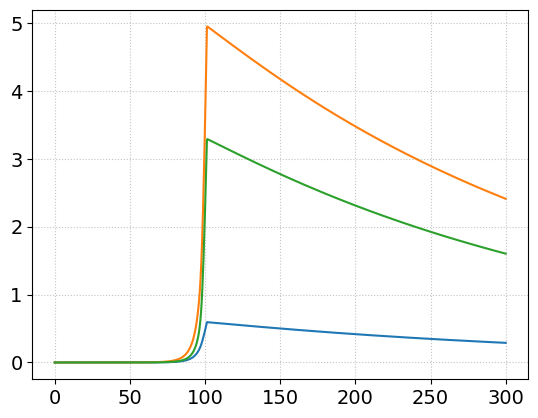

In [11]:
g = 'C14_CO'
#plt.plot(Dome_C.z, c_gases[:,5])
plt.plot(Dome_C.z, C14_closed_gas[g][:,:,0])
#plt.plot(Dome_C.z, C14_closed_atm[g])

In [12]:
pd_DomeC = pd.read_excel('DomeC 14CO data analysis current.xlsx', '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [13]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

[ 1.02573107  0.05882344  0.06822936 12.11135104]
24.390956953078756
2.2173597230071596
0.011181955440460517
2.0072051662826134


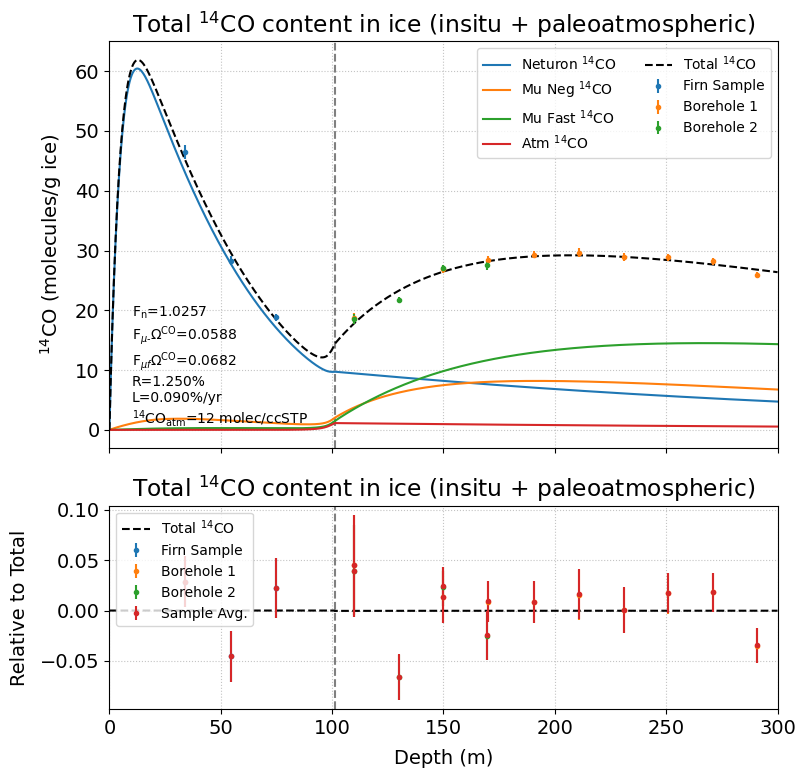

In [43]:
z = Dome_C.z
teller_co = Dome_C.teller_co
lambd = Dome_C.decay_gas['C14_CO']
IceAge = Dome_C.IceAge

i_avg = np.arange(len(CO_exp)).reshape((-1,1))
#i_avg = [[0],[1],[2],[3,12],[13],[4,14],[5,15],[6],[7],[8],[9],[10],[11]]
z_exp_avg = np.array([np.average(z_exp[i]) for i in i_avg])
CO_exp_avg = np.array([np.average(CO_exp[i]) for i in i_avg])
dCO_exp_avg = np.array([np.sqrt(np.sum(dCO_exp[i]**2)+(np.std(CO_exp[i])*2)**2)/len(i) for i in i_avg])
Sigma_inv = np.diag(dCO_exp_avg**(-2))

L1 = 9.0e-4
i_R = np.argmin(abs(L-L1))
R1 = 0.0125
#R1 = 0.01
R = np.zeros(len(L))
R[0] = 1-R1
R[i_R] = R1
R = R/sum(R)

CO_prod = np.array([COS_partition[0,1], 1, 1]).reshape((1,-1,1)) * (C14_grains + C14_cumuleak_closed + C14_closed_gas[g]) @ R
CO_atm = C14_closed_atm[g]

CO_prod_int = interp1d(z, np.concatenate((CO_prod, np.array([CO_atm]).T), axis=1), axis=0)(z_exp_avg)
CO_pi = np.linalg.inv(CO_prod_int.T @ Sigma_inv @ CO_prod_int) @ CO_prod_int.T @ Sigma_inv

f_inv = CO_pi @ CO_exp_avg
print(f_inv)

#f_factors = np.array([1., 0.0538, 0.0685])
#f_factors = np.array([1., 0.0584, 0.0687])
f_factors = f_inv[:3]
P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]])
#F_atm = 12 # atmospheric scale factor
#F_atm = 0
F_atm = f_inv[3]

fig, axes = plt.subplots(2,1, figsize=(8,8), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

for ax in axes:
    ax.axvline(z[teller_co], c='grey', ls='--')
g = 'C14_CO'

CO_grains = (P0_tuning * COS_partition[:,1]) @ C14_grains @ R
CO_closed = (P0_tuning * COS_partition[:,1]) @ C14_cumuleak_closed @ R
CO_openclose = (P0_tuning * COS_partition[:,1]) @ C14_closed_gas[g] @ R
CO_atm = C14_closed_atm[g]*F_atm
CO_all = CO_grains + CO_closed + CO_openclose + CO_atm

CO_prod = (P0_tuning * COS_partition[:,1]).reshape((1,-1,1)) * (C14_grains + C14_cumuleak_closed + C14_closed_gas[g]) @ R

CO_firn = np.copy(CO_all)
CO_firn[teller_co:] = CO_firn[teller_co]*np.exp(lambd*(IceAge[teller_co]-IceAge[teller_co:]))

noleak = C14_noleak @ (P0_tuning * COS_partition[:,1])
rel = CO_firn + noleak
#axes[0].plot(z, CO_grains, label=r'Grain $^{14}$CO')
#axes[0].plot(z, CO_closed, label=r'Closed $^{14}$CO')
#axes[0].plot(z, CO_openclose, label=r'Trapped $^{14}$CO')
#axes[0].plot(z, CO_atm, label=r'Atm $^{14}$CO')

axes[0].plot(z, CO_prod[:,0], label=r'Neturon $^{14}$CO')
axes[0].plot(z, CO_prod[:,1], label=r'Mu Neg $^{14}$CO')
axes[0].plot(z, CO_prod[:,2], label=r'Mu Fast $^{14}$CO')
axes[0].plot(z, CO_atm, label=r'Atm $^{14}$CO')

#axes[0].plot(z, CO_firn, label=r'Firn $^{14}$CO')
#axes[0].plot(z, noleak, label=r'In situ $^{14}$CO')
#axes[0].plot(z, CO_firn + noleak, label=r'Total $^{14}$CO', c='k', ls='--')
axes[0].plot(z, CO_all, label=r'Total $^{14}$CO', c='k', ls='--')

axes[1].plot(z, CO_all/rel-1, label=r'Total $^{14}$CO', c='k', ls='--')

axes[0].set_prop_cycle(None)
axes[1].set_prop_cycle(None)

CO_pred = np.interp(z_exp_avg, z, CO_all)

rel_exp = np.interp(z_exp, z, rel)
for i in range(len(n_samples)):
    j,k = i_samples[i],i_samples[i+1]
    axes[0].errorbar(z_exp[j:k], CO_exp[j:k], dCO_exp[j:k], fmt='.', label=n_samples[i])
    axes[1].errorbar(z_exp[j:k], CO_exp[j:k]/rel_exp[j:k]-1, dCO_exp[j:k]/rel_exp[j:k], fmt='.', label=n_samples[i])
axes[1].errorbar(z_exp_avg, CO_exp_avg/CO_pred-1, dCO_exp_avg/CO_pred, fmt='.', label='Sample Avg.')
    
axes[0].set(
    #xlabel='Depth (m)',
    xlim=(z[0],z[-1]),
    ylabel=r'$^{14}$CO (molecules/g ice)',
    title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
)

axes[1].set(
    xlabel='Depth (m)',
    #xlim=(z[0],z[-1]),
    ylabel='Relative to Total',
    title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
)
axes[0].text(10,1,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2])+'R={:.3f}%\nL={:.3f}%/yr\n'.format(R[i_R]*100,L[i_R]*100)+r'$^{14}\text{CO}_{\text{atm}}$='+'{:.0f} molec/ccSTP'.format(F_atm), fontsize=10)
    
axes[0].legend(fontsize=10, ncols=2)
axes[1].legend(fontsize=10, ncols=1)

chi2 = np.sum((CO_exp_avg-CO_pred)**2/dCO_exp_avg**2)
p = scipy.stats.chi2.sf(chi2, len(CO_exp_avg)-5)
sig = scipy.stats.norm.isf(p*2)
print(chi2)
print(chi2/(len(CO_exp_avg)-5))
print(p)
print(sig)


plt.show()